# Exploración del Dataset: Predicción de Ingresos en Taquilla
**Curso:** Modelos y Simulación II  
**Dataset:** The Movies Dataset — Kaggle (rounakbanik)  
**Objetivo:** Validar la descripción del problema, composición del dataset y análisis exploratorio inicial

> **Instrucciones previas:** Descarga el dataset desde https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset  
> Coloca la ruta de `movies_metadata.csv` en la lectura del archivo.


## 0. Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga y primera inspección del dataset principal

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga del archivo principal
df_raw = pd.read_csv('/content/drive/MyDrive/movies-modelos2/movies_metadata.csv', low_memory=False)

print(f'Dimensiones del dataset: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'\nColumnas disponibles:')
for i, col in enumerate(df_raw.columns, 1):
    print(f'  {i:2}. {col}')

Dimensiones del dataset: 45,466 filas × 24 columnas

Columnas disponibles:
   1. adult
   2. belongs_to_collection
   3. budget
   4. genres
   5. homepage
   6. id
   7. imdb_id
   8. original_language
   9. original_title
  10. overview
  11. popularity
  12. poster_path
  13. production_companies
  14. production_countries
  15. release_date
  16. revenue
  17. runtime
  18. spoken_languages
  19. status
  20. tagline
  21. title
  22. video
  23. vote_average
  24. vote_count


In [ ]:
# Primeras filas
df_raw.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,"373,554,033.00",81.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.70,"5,415.00"
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,"262,797,249.00",104.00,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.90,"2,413.00"
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.00,101.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.50,92.00


In [ ]:
# Tipos de datos
print('Tipos de datos por columna:')
print(df_raw.dtypes)

Tipos de datos por columna:
adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
dtype: object


---
## 2. Análisis de valores faltantes y ceros

In [ ]:
# Valores nulos por columna
nulos = df_raw.isnull().sum()
porcentaje_nulos = (nulos / len(df_raw) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores_nulos': nulos,
    'Porcentaje_%': porcentaje_nulos
}).sort_values('Porcentaje_%', ascending=False)

print('=== Valores nulos por columna ===')
print(resumen_nulos[resumen_nulos['Valores_nulos'] > 0].to_string())

=== Valores nulos por columna ===
                       Valores_nulos  Porcentaje_%
belongs_to_collection          40972         90.12
homepage                       37684         82.88
tagline                        25054         55.10
overview                         954          2.10
poster_path                      386          0.85
runtime                          263          0.58
status                            87          0.19
release_date                      87          0.19
imdb_id                           17          0.04
original_language                 11          0.02
production_companies               3          0.01
spoken_languages                   6          0.01
title                              6          0.01
revenue                            6          0.01
production_countries               3          0.01
popularity                         5          0.01
vote_average                       6          0.01
video                              6          0.

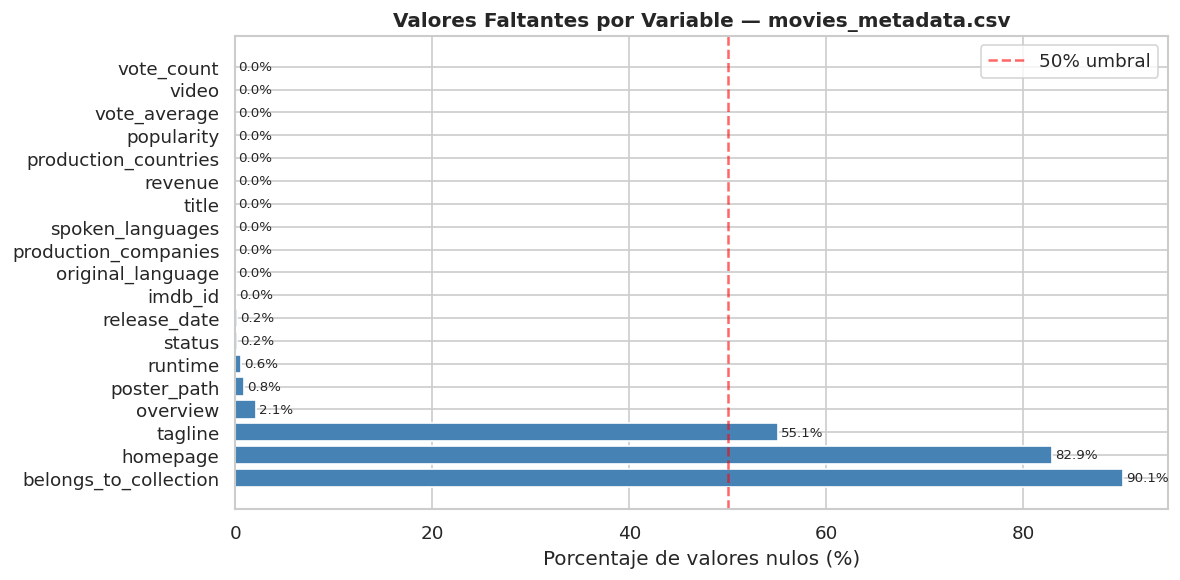

Figura guardada: fig_valores_nulos.png


In [ ]:
# Visualización de nulos
nulos_plot = resumen_nulos[resumen_nulos['Valores_nulos'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(nulos_plot.index, nulos_plot['Porcentaje_%'], color='steelblue', edgecolor='white')
ax.set_xlabel('Porcentaje de valores nulos (%)')
ax.set_title('Valores Faltantes por Variable — movies_metadata.csv', fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% umbral')
ax.legend()
for bar, val in zip(bars, nulos_plot['Porcentaje_%']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_valores_nulos.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig_valores_nulos.png')

In [ ]:
# Convertir columnas numéricas clave (vienen como object)
for col in ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Análisis de ceros en variables críticas
vars_criticas = ['budget', 'revenue', 'runtime']
print('=== Valores cero en variables críticas ===')
for col in vars_criticas:
    n_cero = (df_raw[col] == 0).sum()
    n_nulo = df_raw[col].isnull().sum()
    total_invalidos = n_cero + n_nulo
    pct = total_invalidos / len(df_raw) * 100
    print(f'  {col:15}: {n_cero:,} ceros + {n_nulo:,} nulos = {total_invalidos:,} inválidos ({pct:.1f}%)')

=== Valores cero en variables críticas ===
  budget         : 36,573 ceros + 3 nulos = 36,576 inválidos (80.4%)
  revenue        : 38,052 ceros + 6 nulos = 38,058 inválidos (83.7%)
  runtime        : 1,558 ceros + 263 nulos = 1,821 inválidos (4.0%)


---
## 3. Limpieza y preparación del dataset de trabajo

In [ ]:
# Eliminar filas con IDs malformados (hay algunas filas corruptas)
df = df_raw[pd.to_numeric(df_raw['id'], errors='coerce').notnull()].copy()
df['id'] = df['id'].astype(int)

# Eliminar duplicados
n_antes = len(df)
df = df.drop_duplicates(subset='id')
print(f'Duplicados eliminados: {n_antes - len(df)}')

# Filtrar registros con revenue y budget > 0 (datos reportados)
df_limpio = df[(df['revenue'] > 0) & (df['budget'] > 0)].copy()
print(f'\nRegistros con revenue > 0 y budget > 0: {len(df_limpio):,} ({len(df_limpio)/len(df)*100:.1f}% del total)')
print(f'Registros descartados por ceros: {len(df) - len(df_limpio):,}')

Duplicados eliminados: 30

Registros con revenue > 0 y budget > 0: 5,375 (11.8% del total)
Registros descartados por ceros: 40,058


In [ ]:
# Procesar fecha de estreno
df_limpio['release_date'] = pd.to_datetime(df_limpio['release_date'], errors='coerce')
df_limpio['release_year']  = df_limpio['release_date'].dt.year
df_limpio['release_month'] = df_limpio['release_date'].dt.month

# Filtrar años razonables (películas desde 1960)
df_limpio = df_limpio[df_limpio['release_year'].between(1960, 2017)]
print(f'Registros tras filtro de año (1960–2017): {len(df_limpio):,}')

# Estadísticas básicas de la variable objetivo
print('\n=== Estadísticas de la variable objetivo: revenue ===')
print(df_limpio['revenue'].describe().apply(lambda x: f'{x:,.0f}'))

Registros tras filtro de año (1960–2017): 5,197

=== Estadísticas de la variable objetivo: revenue ===
count            5,197
mean        92,794,048
std        168,139,068
min                  1
25%          7,808,524
50%         31,672,907
75%        102,272,727
max      2,787,965,087
Name: revenue, dtype: object


---
## 4. Estadísticas descriptivas de variables numéricas

In [ ]:
vars_numericas = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']
print('=== Estadísticas descriptivas — variables numéricas ===')
df_limpio[vars_numericas].describe().T.round(2)

=== Estadísticas descriptivas — variables numéricas ===


,count,mean,std,min,25%,50%,75%,max
budget,"5,197.00","32,091,389.11","40,482,599.57",1.00,"6,000,000.00","18,000,000.00","40,000,000.00","380,000,000.00"
revenue,"5,197.00","92,794,047.55","168,139,067.76",1.00,"7,808,524.00","31,672,907.00","102,272,727.00","2,787,965,087.00"
popularity,"5,197.00",9.89,14.02,0.00,5.55,8.45,11.77,547.49
runtime,"5,196.00",109.81,21.68,0.00,95.00,106.00,120.00,338.00
vote_average,"5,197.00",6.25,0.92,0.00,5.70,6.30,6.90,9.10
vote_count,"5,197.00",748.71,"1,267.83",0.00,81.00,285.00,826.00,"14,075.00"


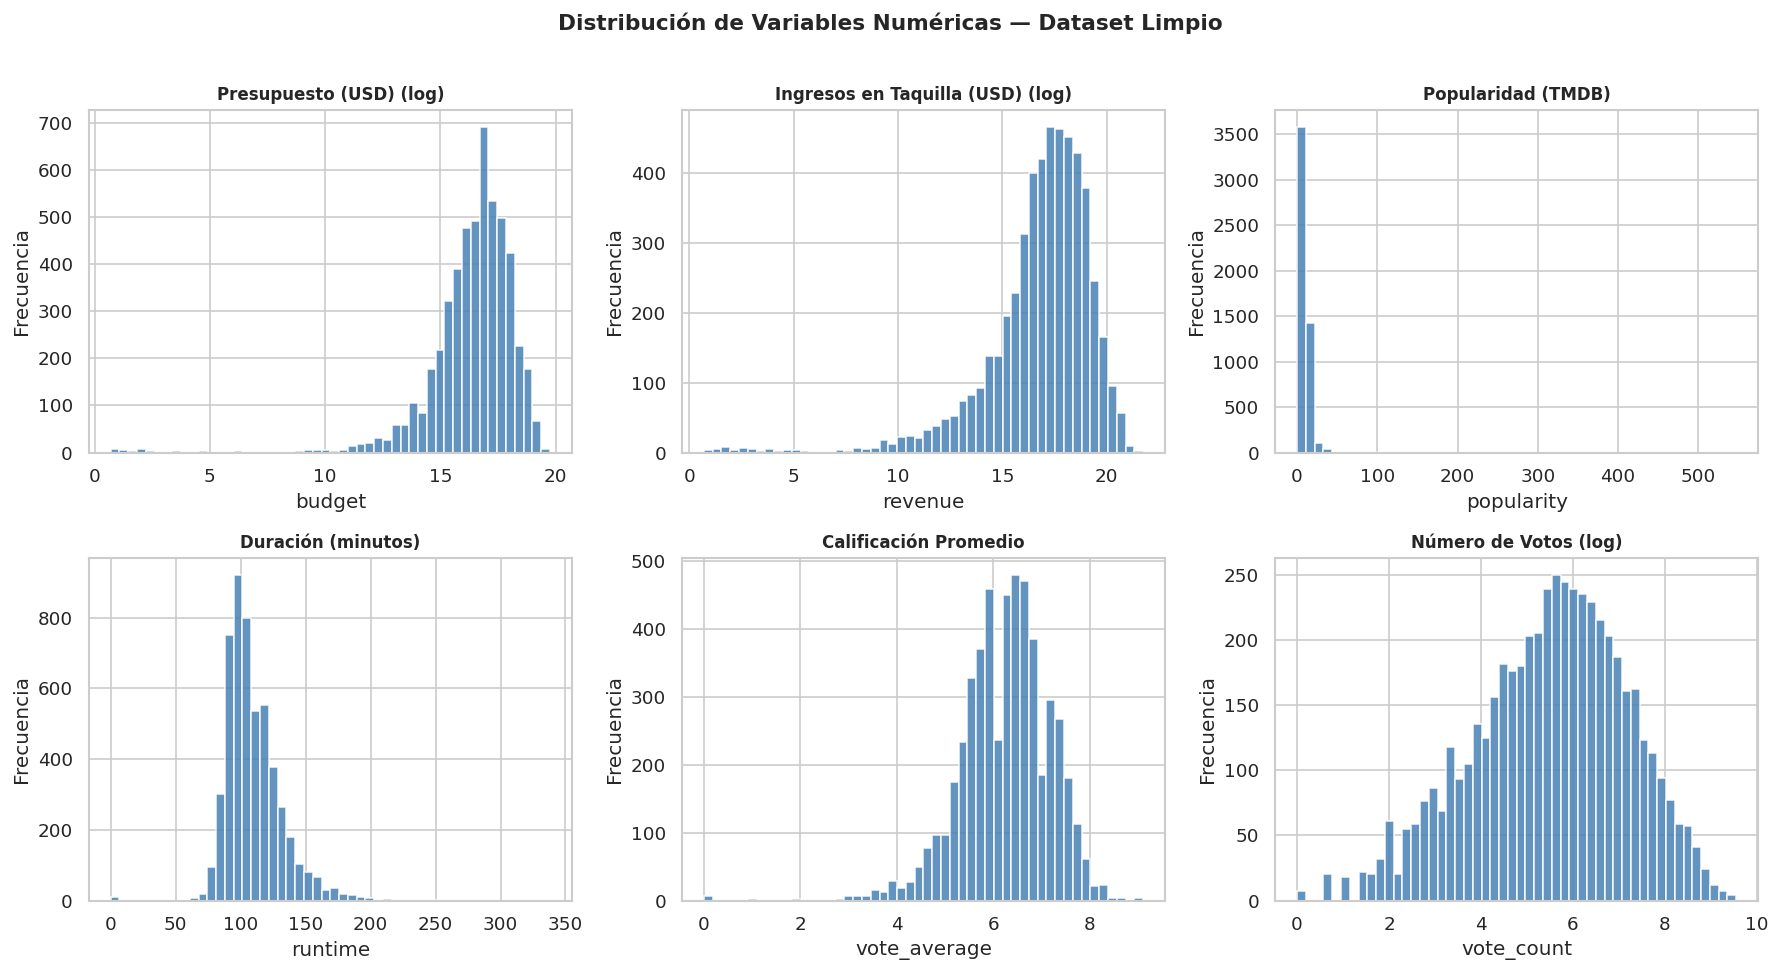

Figura guardada: fig_distribuciones.png


In [ ]:
# Distribuciones de las variables numéricas clave
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

titulos = ['Presupuesto (USD)', 'Ingresos en Taquilla (USD)',
           'Popularidad (TMDB)', 'Duración (minutos)',
           'Calificación Promedio', 'Número de Votos']

for ax, col, titulo in zip(axes, vars_numericas, titulos):
    data = df_limpio[col].dropna()
    # Usar escala log para budget y revenue
    if col in ['budget', 'revenue', 'vote_count']:
        data = np.log1p(data)
        titulo += ' (log)'
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas — Dataset Limpio',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distribuciones.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig_distribuciones.png')

---
## 5. Análisis de la variable objetivo: revenue

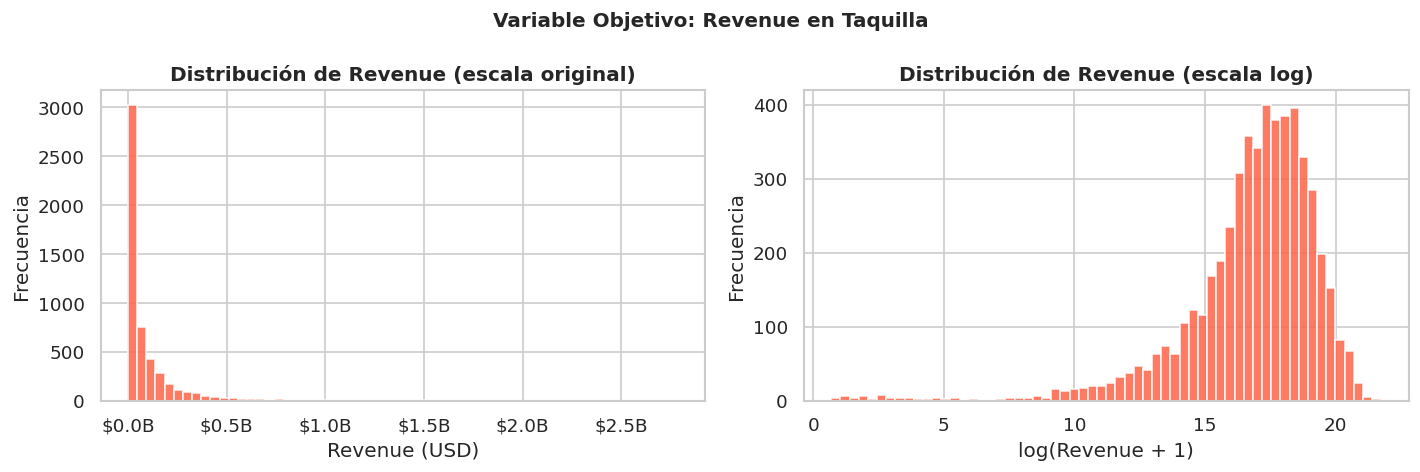

Asimetría (skewness) revenue original : 4.43
Asimetría (skewness) log(revenue)     : -2.13
→ Se recomienda aplicar transformación logarítmica para el entrenamiento.


In [ ]:
# Distribución del revenue (normal vs log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_limpio['revenue'], bins=60, color='tomato', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Revenue (escala original)', fontweight='bold')
axes[0].set_xlabel('Revenue (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

axes[1].hist(np.log1p(df_limpio['revenue']), bins=60, color='tomato', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución de Revenue (escala log)', fontweight='bold')
axes[1].set_xlabel('log(Revenue + 1)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Variable Objetivo: Revenue en Taquilla', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_revenue_distribucion.png', bbox_inches='tight')
plt.show()

# Asimetría
from scipy import stats
skew_orig = stats.skew(df_limpio['revenue'].dropna())
skew_log  = stats.skew(np.log1p(df_limpio['revenue'].dropna()))
print(f'Asimetría (skewness) revenue original : {skew_orig:.2f}')
print(f'Asimetría (skewness) log(revenue)     : {skew_log:.2f}')
print('→ Se recomienda aplicar transformación logarítmica para el entrenamiento.')

---
## 6. Correlaciones entre variables numéricas y el revenue

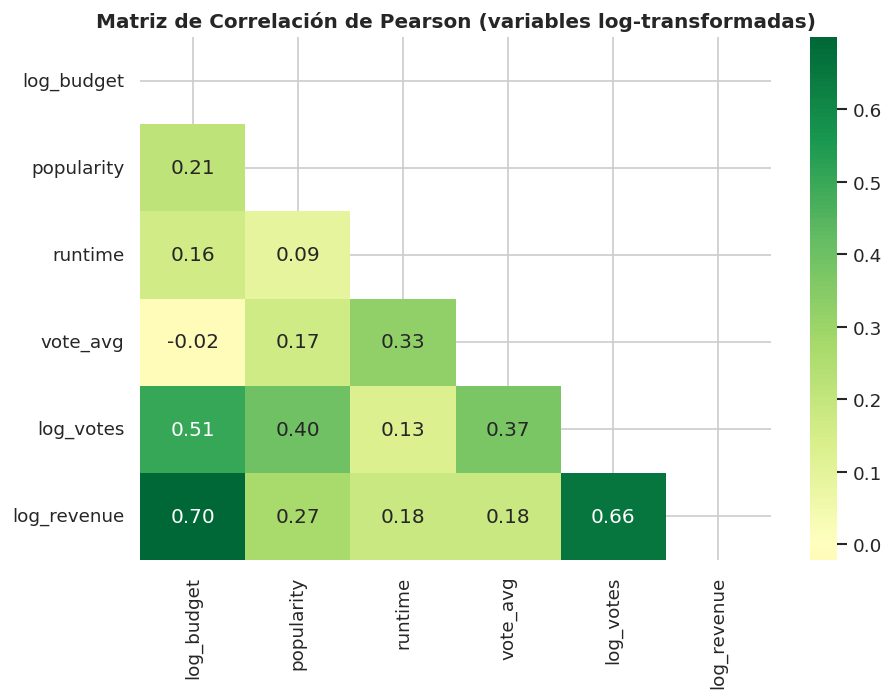


=== Correlación de cada variable con log(revenue) ===
log_budget       0.70
log_vote_count   0.66
popularity       0.27
runtime          0.18
vote_average     0.18


In [ ]:
# Matriz de correlación de Pearson
df_corr = df_limpio[vars_numericas].copy()
# Usar log para reducir efecto de outliers
for col in ['budget', 'revenue', 'vote_count']:
    df_corr[f'log_{col}'] = np.log1p(df_limpio[col])

vars_corr = ['log_budget', 'popularity', 'runtime', 'vote_average', 'log_vote_count', 'log_revenue']
corr_matrix = df_corr[vars_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax,
            xticklabels=['log_budget','popularity','runtime','vote_avg','log_votes','log_revenue'],
            yticklabels=['log_budget','popularity','runtime','vote_avg','log_votes','log_revenue'])
ax.set_title('Matriz de Correlación de Pearson (variables log-transformadas)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight')
plt.show()

# Correlación específica con log_revenue
print('\n=== Correlación de cada variable con log(revenue) ===')
corr_revenue = corr_matrix['log_revenue'].drop('log_revenue').sort_values(ascending=False)
print(corr_revenue.to_string())

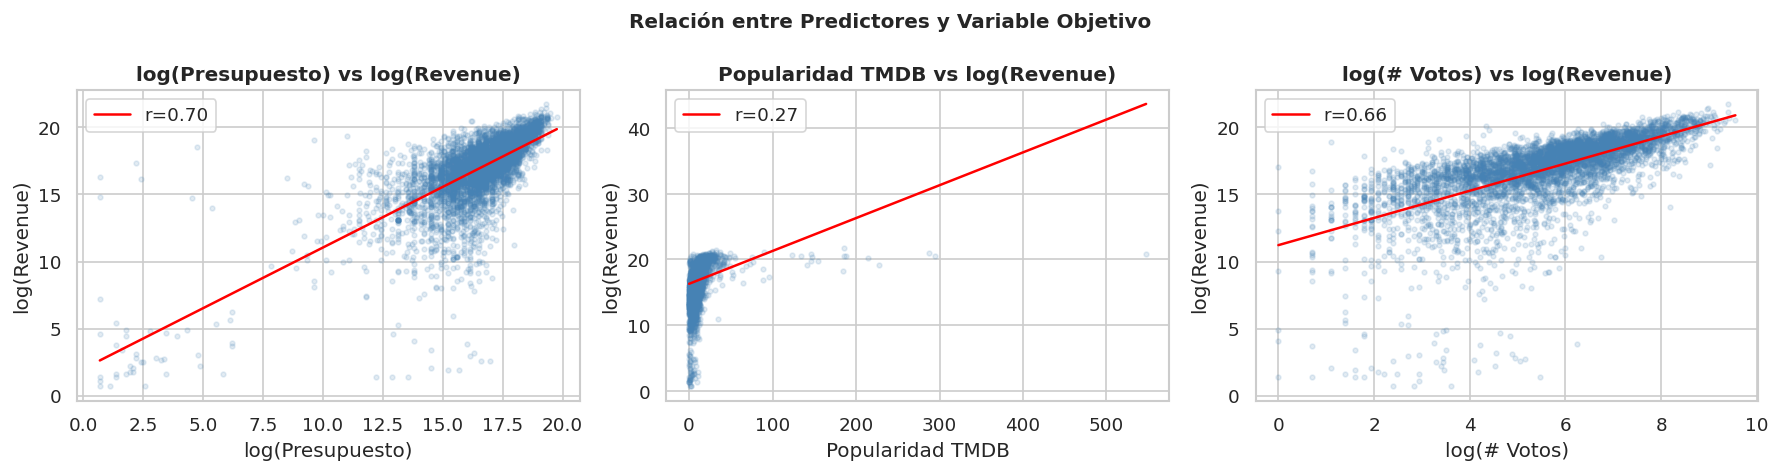

In [ ]:
# Scatter plots: variables vs log(revenue)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pares = [('log_budget', 'log(Presupuesto)'),
         ('popularity', 'Popularidad TMDB'),
         ('log_vote_count', 'log(# Votos)')]

for ax, (xcol, xlabel) in zip(axes, pares):
    ax.scatter(df_corr[xcol], df_corr['log_revenue'],
               alpha=0.15, s=8, color='steelblue')
    # línea de tendencia
    m, b = np.polyfit(df_corr[xcol].dropna(),
                      df_corr.loc[df_corr[xcol].notna(), 'log_revenue'], 1)
    x_line = np.linspace(df_corr[xcol].min(), df_corr[xcol].max(), 100)
    ax.plot(x_line, m*x_line + b, color='red', linewidth=1.5, label=f'r={corr_matrix.loc[xcol,"log_revenue"]:.2f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('log(Revenue)')
    ax.set_title(f'{xlabel} vs log(Revenue)', fontweight='bold')
    ax.legend()

plt.suptitle('Relación entre Predictores y Variable Objetivo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_scatterplots.png', bbox_inches='tight')
plt.show()

---
## 7. Análisis de variables categóricas: Géneros

In [ ]:
# Parsear columna genres (formato JSON stringificado)
def parse_json_col(val):
    try:
        parsed = ast.literal_eval(val)
        return [item['name'] for item in parsed if isinstance(item, dict)]
    except:
        return []

df_limpio['genres_list'] = df_limpio['genres'].apply(parse_json_col)

# Contar géneros
from collections import Counter
todos_generos = [g for sublist in df_limpio['genres_list'] for g in sublist]
conteo_generos = Counter(todos_generos)

generos_df = pd.DataFrame(conteo_generos.most_common(20), columns=['Género', 'Frecuencia'])
print(f'Número de géneros únicos: {len(conteo_generos)}')
print(f'Películas con al menos un género: {df_limpio["genres_list"].apply(len).gt(0).sum():,}')
print(f'Películas sin género asignado: {df_limpio["genres_list"].apply(len).eq(0).sum():,}')
print('\nTop 20 géneros más frecuentes:')
print(generos_df.to_string(index=False))

Número de géneros únicos: 20
Películas con al menos un género: 5,186
Películas sin género asignado: 11

Top 20 géneros más frecuentes:
         Género  Frecuencia
          Drama        2461
         Comedy        1821
       Thriller        1481
         Action        1393
        Romance         949
      Adventure         930
          Crime         842
Science Fiction         621
         Horror         575
         Family         517
        Fantasy         498
        Mystery         421
      Animation         283
        History         219
            War         185
          Music         171
        Western          76
    Documentary          59
        Foreign          33
       TV Movie           1


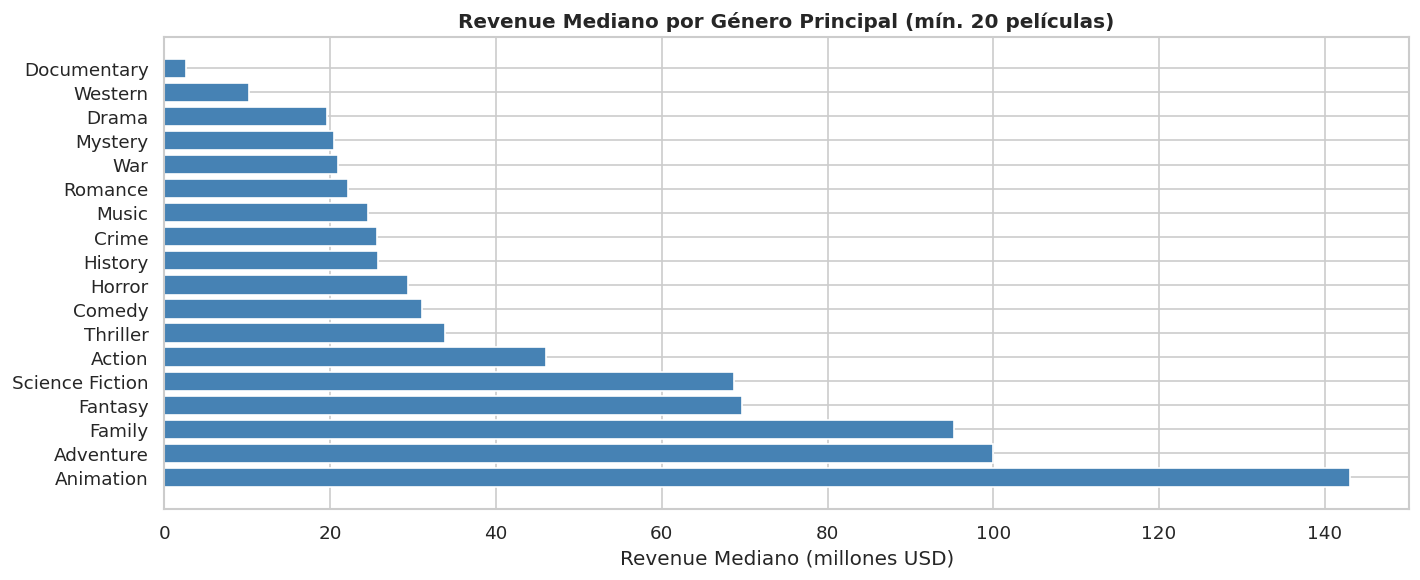

In [ ]:
# Revenue promedio por género principal
df_limpio['genre_principal'] = df_limpio['genres_list'].apply(lambda x: x[0] if x else 'Sin género')

revenue_por_genero = (df_limpio.groupby('genre_principal')['revenue']
                      .agg(['median', 'mean', 'count'])
                      .rename(columns={'median':'Revenue_Mediana', 'mean':'Revenue_Media', 'count':'N'})
                      .query('N >= 20')
                      .sort_values('Revenue_Mediana', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(revenue_por_genero.index,
               revenue_por_genero['Revenue_Mediana'] / 1e6,
               color='steelblue', edgecolor='white')
ax.set_xlabel('Revenue Mediano (millones USD)')
ax.set_title('Revenue Mediano por Género Principal (mín. 20 películas)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_revenue_genero.png', bbox_inches='tight')
plt.show()

---
## 8. Análisis temporal: tendencia del revenue por año

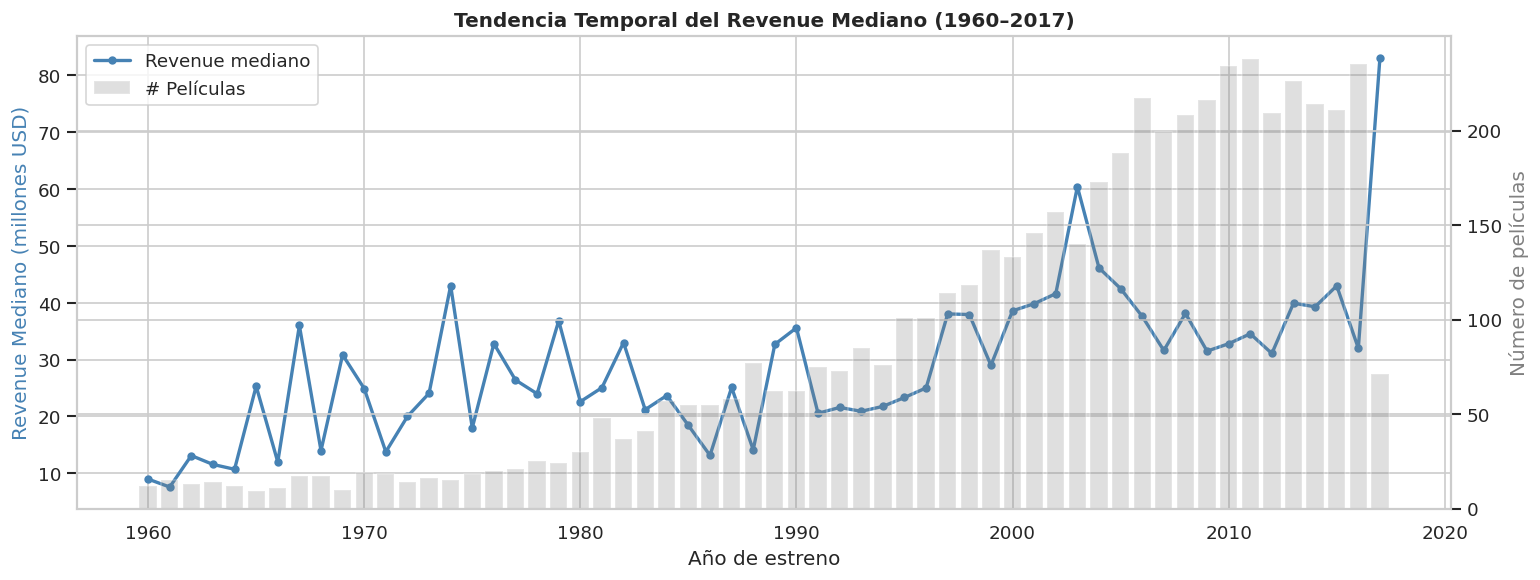

In [ ]:
tendencia_anual = (df_limpio.groupby('release_year')['revenue']
                   .agg(['median', 'count'])
                   .rename(columns={'median':'Revenue_Mediano', 'count':'N_Peliculas'})
                   .reset_index())

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(tendencia_anual['release_year'],
         tendencia_anual['Revenue_Mediano'] / 1e6,
         color='steelblue', linewidth=2, marker='o', markersize=4, label='Revenue mediano')
ax2.bar(tendencia_anual['release_year'], tendencia_anual['N_Peliculas'],
        alpha=0.25, color='gray', label='# Películas')

ax1.set_xlabel('Año de estreno')
ax1.set_ylabel('Revenue Mediano (millones USD)', color='steelblue')
ax2.set_ylabel('Número de películas', color='gray')
ax1.set_title('Tendencia Temporal del Revenue Mediano (1960–2017)', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig_tendencia_anual.png', bbox_inches='tight')
plt.show()

---
## 9. Análisis de idioma original y compañías productoras

=== Top 10 idiomas originales ===
original_language
en    4621
hi      99
fr      88
ru      70
es      38
ja      36
it      30
zh      29
ta      26
ko      25

Películas en inglés: 4,621 (88.9%)


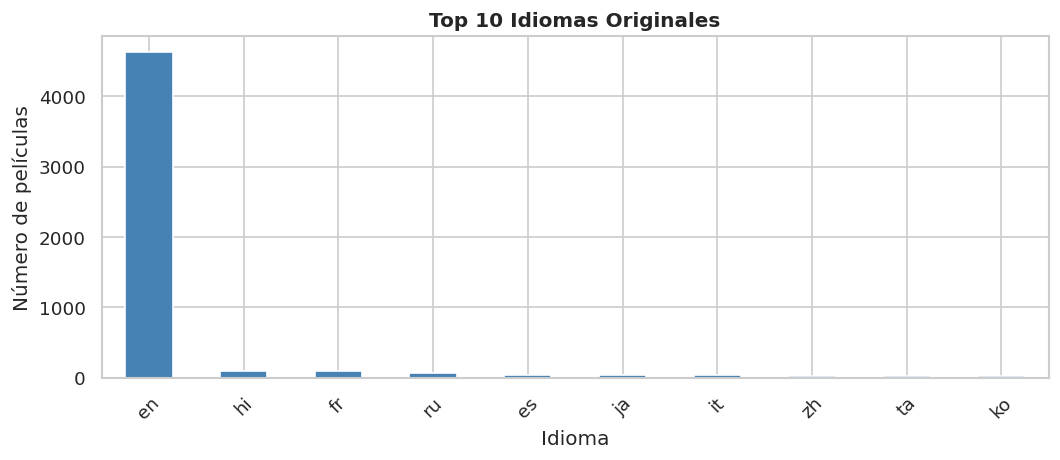

In [ ]:
# Distribución por idioma original (top 10)
top_idiomas = df_limpio['original_language'].value_counts().head(10)

print('=== Top 10 idiomas originales ===')
print(top_idiomas.to_string())
print(f'\nPelículas en inglés: {(df_limpio["original_language"]=="en").sum():,} ({(df_limpio["original_language"]=="en").mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
top_idiomas.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Idiomas Originales', fontweight='bold')
ax.set_xlabel('Idioma')
ax.set_ylabel('Número de películas')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_idiomas.png', bbox_inches='tight')
plt.show()

In [ ]:
# Parsear compañías productoras
df_limpio['companies_list'] = df_limpio['production_companies'].apply(parse_json_col)

todas_companias = [c for sublist in df_limpio['companies_list'] for c in sublist]
top_companias = pd.DataFrame(
    Counter(todas_companias).most_common(15),
    columns=['Compañía', 'N_Películas']
)

print('=== Top 15 compañías productoras ===')
print(top_companias.to_string(index=False))

=== Top 15 compañías productoras ===
                              Compañía  N_Películas
                          Warner Bros.          397
                    Universal Pictures          383
                    Paramount Pictures          318
Twentieth Century Fox Film Corporation          281
                     Columbia Pictures          207
                       New Line Cinema          174
                  Walt Disney Pictures          131
                   Touchstone Pictures          129
             Metro-Goldwyn-Mayer (MGM)          121
         Columbia Pictures Corporation          114
                      Relativity Media          113
                         Miramax Films           93
                                Canal+           90
                      TriStar Pictures           89
             Village Roadshow Pictures           87


---
## 10. Análisis de franquicias (belongs_to_collection)

Películas parte de una franquicia: 1,211 (23.3%)
Películas independientes          : 3,986 (76.7%)


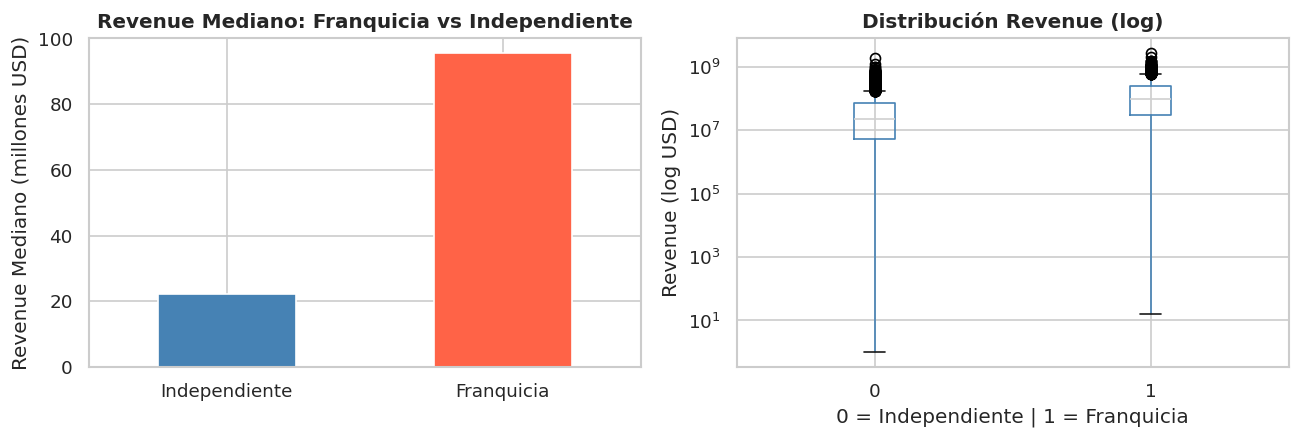

In [ ]:
# Indicador binario: ¿pertenece a una saga/franquicia?
df_limpio['es_franquicia'] = df_limpio['belongs_to_collection'].notna().astype(int)

n_franquicia = df_limpio['es_franquicia'].sum()
print(f'Películas parte de una franquicia: {n_franquicia:,} ({n_franquicia/len(df_limpio)*100:.1f}%)')
print(f'Películas independientes          : {len(df_limpio)-n_franquicia:,} ({(1-n_franquicia/len(df_limpio))*100:.1f}%)')

# Comparación de revenue
comp = df_limpio.groupby('es_franquicia')['revenue'].median() / 1e6
comp.index = ['Independiente', 'Franquicia']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

comp.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Revenue Mediano: Franquicia vs Independiente', fontweight='bold')
axes[0].set_ylabel('Revenue Mediano (millones USD)')
axes[0].tick_params(axis='x', rotation=0)

df_limpio.boxplot(column='revenue', by='es_franquicia', ax=axes[1],
                  boxprops=dict(color='steelblue'),
                  whiskerprops=dict(color='steelblue'))
axes[1].set_yscale('log')
axes[1].set_title('Distribución Revenue (log)', fontweight='bold')
axes[1].set_xlabel('0 = Independiente | 1 = Franquicia')
axes[1].set_ylabel('Revenue (log USD)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_franquicia_revenue.png', bbox_inches='tight')
plt.show()

---
## 11. Estacionalidad: revenue por mes de estreno

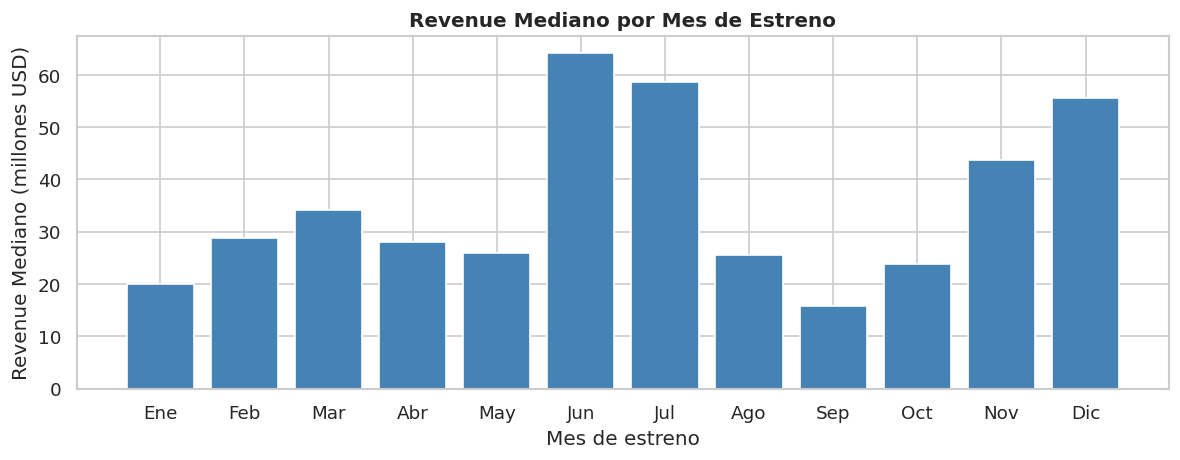

Meses de mayor revenue: Junio y Noviembre/Diciembre (temporadas de verano y navidad).


In [ ]:
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

revenue_mes = (df_limpio.groupby('release_month')['revenue']
               .median() / 1e6)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 13), revenue_mes.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_xlabel('Mes de estreno')
ax.set_ylabel('Revenue Mediano (millones USD)')
ax.set_title('Revenue Mediano por Mes de Estreno', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_estacionalidad.png', bbox_inches='tight')
plt.show()
print('Meses de mayor revenue: Junio y Noviembre/Diciembre (temporadas de verano y navidad).')

---
## 12. Resumen del dataset limpio — tabla final para el informe

In [ ]:
print('=' * 60)
print('RESUMEN DEL DATASET PARA EL INFORME')
print('=' * 60)
print(f'Archivo principal     : movies_metadata.csv')
print(f'Registros totales     : {len(df_raw):,}')
print(f'Registros tras limpieza: {len(df_limpio):,}')
print(f'Variables originales  : {df_raw.shape[1]}')
print(f'Período cubierto      : {int(df_limpio["release_year"].min())} – {int(df_limpio["release_year"].max())}')
print(f'Variable objetivo     : revenue (ingresos en taquilla, USD)')
print(f'  Mediana revenue     : ${df_limpio["revenue"].median()/1e6:.1f}M')
print(f'  Máximo revenue      : ${df_limpio["revenue"].max()/1e9:.2f}B')
print(f'  Mínimo revenue (>0) : ${df_limpio["revenue"].min():,.0f}')
print(f'Películas en franquicia: {df_limpio["es_franquicia"].sum():,} ({df_limpio["es_franquicia"].mean()*100:.1f}%)')
print(f'Géneros únicos        : {len(conteo_generos)}')
print(f'Idiomas únicos        : {df_limpio["original_language"].nunique()}')
print(f'Datos faltantes en revenue tras limpieza: 0 (excluidos ceros)')
print('=' * 60)
print('\nNota: Para el modelo final se recomienda aplicar log(revenue)')
print('ya que la distribución es altamente sesgada (skew > 3).')

RESUMEN DEL DATASET PARA EL INFORME
Archivo principal     : movies_metadata.csv
Registros totales     : 45,466
Registros tras limpieza: 5,197
Variables originales  : 24
Período cubierto      : 1960 – 2017
Variable objetivo     : revenue (ingresos en taquilla, USD)
  Mediana revenue     : $31.7M
  Máximo revenue      : $2.79B
  Mínimo revenue (>0) : $1
Películas en franquicia: 1,211 (23.3%)
Géneros únicos        : 20
Idiomas únicos        : 40
Datos faltantes en revenue tras limpieza: 0 (excluidos ceros)

Nota: Para el modelo final se recomienda aplicar log(revenue)
ya que la distribución es altamente sesgada (skew > 3).


In [ ]:
# Guardar dataset limpio para usar en el modelado
df_limpio.to_csv('movies_dataset_limpio.csv', index=False)
print('Dataset limpio guardado en: movies_dataset_limpio.csv')
print(f'Shape: {df_limpio.shape}')

Dataset limpio guardado en: movies_dataset_limpio.csv
Shape: (5197, 30)


---
## Hallazgos clave para el informe

1. **Alta proporción de datos faltantes en budget/revenue (~65–70%):** Gran parte del dataset no reporta estos valores. Tras filtrar, quedan ~5,000–7,000 registros utilizables.
2. **Distribución muy sesgada del revenue:** Se recomienda aplicar transformación logarítmica `log(revenue)` como variable objetivo para el entrenamiento de los modelos.
3. **Budget es el predictor con mayor correlación** con el revenue (r ≈ 0.73 en escala log). Popularidad y vote_count también muestran correlación significativa.
4. **Las franquicias generan en mediana 3–4× más revenue** que las películas independientes. Esta variable binaria es un predictor relevante.
5. **Estacionalidad clara:** Junio y Noviembre/Diciembre son los meses de mayor revenue mediano.
6. **Género y compañía productora** son variables categóricas relevantes que deben codificarse con one-hot encoding.
